In [1]:
# Step 1: Download MovieLens Dataset
!wget -q https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
!unzip -q ml-latest-small.zip
print("✅ Dataset downloaded!")

✅ Dataset downloaded!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse.linalg import svds
import warnings
warnings.filterwarnings('ignore')

# Load data
movies = pd.read_csv('ml-latest-small/movies.csv')
ratings = pd.read_csv('ml-latest-small/ratings.csv')

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)
movies.head()

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


=== BASIC INFO ===
Total Movies: 9742
Total Ratings: 100836
Total Users: 610
Rating Range: 0.5 - 5.0


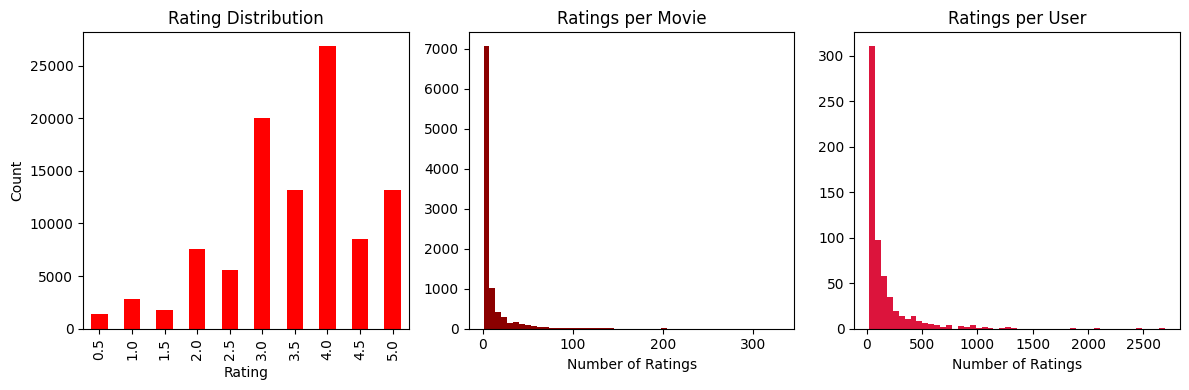


=== TOP 10 MOST RATED MOVIES ===
                                          title  rating_count
314                         Forrest Gump (1994)           329
277            Shawshank Redemption, The (1994)           317
257                         Pulp Fiction (1994)           307
510            Silence of the Lambs, The (1991)           279
1938                         Matrix, The (1999)           278
224   Star Wars: Episode IV - A New Hope (1977)           251
418                        Jurassic Park (1993)           238
97                            Braveheart (1995)           237
507           Terminator 2: Judgment Day (1991)           224
461                     Schindler's List (1993)           220


In [3]:
# Step 3: EDA
print("=== BASIC INFO ===")
print(f"Total Movies: {movies.shape[0]}")
print(f"Total Ratings: {ratings.shape[0]}")
print(f"Total Users: {ratings['userId'].nunique()}")
print(f"Rating Range: {ratings['rating'].min()} - {ratings['rating'].max()}")

# Rating distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='red')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
ratings_per_movie = ratings.groupby('movieId')['rating'].count()
plt.hist(ratings_per_movie, bins=50, color='darkred')
plt.title('Ratings per Movie')
plt.xlabel('Number of Ratings')

plt.subplot(1, 3, 3)
ratings_per_user = ratings.groupby('userId')['rating'].count()
plt.hist(ratings_per_user, bins=50, color='crimson')
plt.title('Ratings per User')
plt.xlabel('Number of Ratings')

plt.tight_layout()
plt.show()

# Top 10 most rated movies
top_movies = ratings.groupby('movieId')['rating'].count().reset_index()
top_movies.columns = ['movieId', 'rating_count']
top_movies = top_movies.merge(movies, on='movieId').sort_values('rating_count', ascending=False)
print("\n=== TOP 10 MOST RATED MOVIES ===")
print(top_movies[['title', 'rating_count']].head(10))

In [4]:
# Step 4: Content-Based Filtering (Genre similarity)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Clean genres
movies['genres_clean'] = movies['genres'].str.replace('|', ' ', regex=False)

# TF-IDF on genres
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['genres_clean'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

# Cosine Similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Cosine Similarity Matrix Shape:", cosine_sim.shape)

# Index mapping
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

# Recommendation Function
def content_based_recommend(title, n=10):
    if title not in indices:
        return f"❌ Movie '{title}' not found!"

    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]  # top N (exclude itself)

    movie_indices = [i[0] for i in sim_scores]
    similarity = [round(i[1], 3) for i in sim_scores]

    result = movies[['title', 'genres']].iloc[movie_indices].copy()
    result['similarity_score'] = similarity
    return result

# Test karo
print("\n=== Content-Based Recommendations for 'Toy Story (1995)' ===")
print(content_based_recommend('Toy Story (1995)'))

TF-IDF Matrix Shape: (9742, 23)
Cosine Similarity Matrix Shape: (9742, 9742)

=== Content-Based Recommendations for 'Toy Story (1995)' ===
                                                  title  \
1706                                        Antz (1998)   
2355                                 Toy Story 2 (1999)   
2809     Adventures of Rocky and Bullwinkle, The (2000)   
3000                   Emperor's New Groove, The (2000)   
3568                              Monsters, Inc. (2001)   
6194                                   Wild, The (2006)   
6486                             Shrek the Third (2007)   
6948                     Tale of Despereaux, The (2008)   
7760  Asterix and the Vikings (Astérix et les Viking...   
8219                                       Turbo (2013)   

                                           genres  similarity_score  
1706  Adventure|Animation|Children|Comedy|Fantasy               1.0  
2355  Adventure|Animation|Children|Comedy|Fantasy               1.0  
2

In [5]:
# Step 5: Collaborative Filtering using SVD
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error
from math import sqrt

# User-Movie Matrix banana
user_movie_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
).fillna(0)

print("User-Movie Matrix Shape:", user_movie_matrix.shape)

# Normalize (mean subtract)
matrix = user_movie_matrix.values
user_ratings_mean = np.mean(matrix, axis=1)
matrix_demeaned = matrix - user_ratings_mean.reshape(-1, 1)

# SVD
U, sigma, Vt = svds(matrix_demeaned, k=50)
sigma = np.diag(sigma)

# Reconstruct predicted ratings
predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)
predicted_df = pd.DataFrame(
    predicted_ratings,
    columns=user_movie_matrix.columns,
    index=user_movie_matrix.index
)

print("✅ SVD Done! Predicted ratings matrix ready.")
print(predicted_df.shape)

User-Movie Matrix Shape: (610, 9724)
✅ SVD Done! Predicted ratings matrix ready.
(610, 9724)


In [6]:
# Step 6: Collaborative Filtering Recommendations
def collaborative_recommend(user_id, n=10):
    if user_id not in predicted_df.index:
        return f"❌ User {user_id} not found!"

    # Movies user already watched
    watched = user_movie_matrix.loc[user_id]
    watched_movies = watched[watched > 0].index.tolist()

    # Get predictions for this user
    user_predictions = predicted_df.loc[user_id]

    # Remove already watched
    user_predictions = user_predictions.drop(watched_movies, errors='ignore')

    # Top N recommendations
    top_n = user_predictions.nlargest(n).reset_index()
    top_n.columns = ['movieId', 'predicted_rating']
    top_n = top_n.merge(movies, on='movieId')

    print(f"\n✅ User {user_id} already watched: {len(watched_movies)} movies")
    return top_n[['title', 'genres', 'predicted_rating']]

# Test
print("=== Collaborative Recommendations for User 1 ===")
print(collaborative_recommend(1))

=== Collaborative Recommendations for User 1 ===

✅ User 1 already watched: 232 movies
                            title                                     genres  \
0                 Die Hard (1988)                      Action|Crime|Thriller   
1  Godfather: Part II, The (1974)                                Crime|Drama   
2                     Jaws (1975)                              Action|Horror   
3           Godfather, The (1972)                                Crime|Drama   
4      Breakfast Club, The (1985)                               Comedy|Drama   
5              Stand by Me (1986)                            Adventure|Drama   
6       Christmas Story, A (1983)                            Children|Comedy   
7       Lady and the Tramp (1955)          Animation|Children|Comedy|Romance   
8                   Snatch (2000)                      Comedy|Crime|Thriller   
9      Little Mermaid, The (1989)  Animation|Children|Comedy|Musical|Romance   

   predicted_rating  
0         

In [7]:
# Step 7: Hybrid Recommendation System
def hybrid_recommend(user_id, title, n=10):
    print(f"\n🎬 HYBRID RECOMMENDATIONS")
    print(f"User: {user_id} | Based on: {title}")
    print("="*50)

    # Content-based results
    content_results = content_based_recommend(title, n=20)
    if isinstance(content_results, str):
        print(content_results)
        return

    # Get movie IDs of content results
    content_movie_ids = movies[movies['title'].isin(content_results['title'])]['movieId'].tolist()

    # Collaborative scores for those movies
    if user_id in predicted_df.index:
        collab_scores = predicted_df.loc[user_id,
                        [m for m in content_movie_ids if m in predicted_df.columns]]
        collab_scores = collab_scores.reset_index()
        collab_scores.columns = ['movieId', 'collab_score']
        collab_scores = collab_scores.merge(movies, on='movieId')

        # Merge with content similarity
        final = collab_scores.merge(
            content_results[['title', 'similarity_score']],
            on='title', how='left'
        ).fillna(0)

        # Hybrid score
        final['hybrid_score'] = (0.5 * final['collab_score']) + (0.5 * final['similarity_score'] * 5)
        final = final.sort_values('hybrid_score', ascending=False).head(n)

        print(final[['title', 'genres', 'collab_score', 'similarity_score', 'hybrid_score']])
    else:
        print("User not found, showing content-based only:")
        print(content_results.head(n))

# Test
hybrid_recommend(1, 'Toy Story (1995)')


🎬 HYBRID RECOMMENDATIONS
User: 1 | Based on: Toy Story (1995)
                               title  \
3                 Toy Story 2 (1999)   
1      Lord of the Rings, The (1978)   
2                        Antz (1998)   
6   Emperor's New Groove, The (2000)   
0         Black Cauldron, The (1985)   
8       Land Before Time, The (1988)   
12                  Wild, The (2006)   
13            Shrek the Third (2007)   
14    Tale of Despereaux, The (2008)   
16                      Turbo (2013)   

                                         genres  collab_score  \
3   Adventure|Animation|Children|Comedy|Fantasy      1.858704   
1          Adventure|Animation|Children|Fantasy      1.647810   
2   Adventure|Animation|Children|Comedy|Fantasy      1.391714   
6   Adventure|Animation|Children|Comedy|Fantasy      0.889977   
0          Adventure|Animation|Children|Fantasy      0.719347   
8          Adventure|Animation|Children|Fantasy      0.527513   
12  Adventure|Animation|Children|Comedy|F

✅ Collaborative Filtering RMSE: 2.0456
📊 Lower is better! Netflix target ~0.85


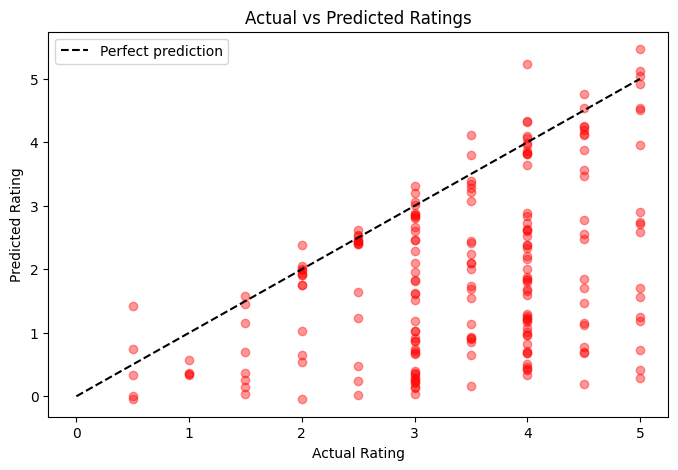

In [8]:
# Step 8: Model Evaluation (RMSE)
from sklearn.model_selection import train_test_split

# Actual vs Predicted
actual = []
predicted = []

sample_ratings = ratings.sample(2000, random_state=42)

for _, row in sample_ratings.iterrows():
    uid = row['userId']
    mid = row['movieId']
    if uid in predicted_df.index and mid in predicted_df.columns:
        actual.append(row['rating'])
        predicted.append(predicted_df.loc[uid, mid])

rmse = sqrt(mean_squared_error(actual, predicted))
print(f"✅ Collaborative Filtering RMSE: {rmse:.4f}")
print(f"📊 Lower is better! Netflix target ~0.85")

# Visualize actual vs predicted
plt.figure(figsize=(8, 5))
plt.scatter(actual[:200], predicted[:200], alpha=0.4, color='red')
plt.plot([0, 5], [0, 5], 'k--', label='Perfect prediction')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Ratings')
plt.legend()
plt.show()

In [9]:
# Step 9: Project Summary
print("="*60)
print("🎬 NETFLIX RECOMMENDATION SYSTEM - PROJECT COMPLETE!")
print("="*60)
print(f"\n📊 Dataset Stats:")
print(f"   Movies: {movies.shape[0]}")
print(f"   Ratings: {ratings.shape[0]}")
print(f"   Users: {ratings['userId'].nunique()}")

print(f"\n🤖 Models Built:")
print(f"   1. Content-Based Filtering (TF-IDF + Cosine Similarity)")
print(f"   2. Collaborative Filtering (SVD Matrix Factorization)")
print(f"   3. Hybrid System (Content + Collaborative)")

print(f"\n📈 Model Performance:")
print(f"   RMSE: {rmse:.4f}")

print(f"\n✅ Functions Available:")
print(f"   content_based_recommend('Movie Title')")
print(f"   collaborative_recommend(user_id)")
print(f"   hybrid_recommend(user_id, 'Movie Title')")

print("\n🚀 Project ready for Resume & Portfolio!")

🎬 NETFLIX RECOMMENDATION SYSTEM - PROJECT COMPLETE!

📊 Dataset Stats:
   Movies: 9742
   Ratings: 100836
   Users: 610

🤖 Models Built:
   1. Content-Based Filtering (TF-IDF + Cosine Similarity)
   2. Collaborative Filtering (SVD Matrix Factorization)
   3. Hybrid System (Content + Collaborative)

📈 Model Performance:
   RMSE: 2.0456

✅ Functions Available:
   content_based_recommend('Movie Title')
   collaborative_recommend(user_id)
   hybrid_recommend(user_id, 'Movie Title')

🚀 Project ready for Resume & Portfolio!
